# LendingClub Credit Scorecard — Build & Out-of-Time Validation

Builds a traditional WOE/logistic-regression credit scorecard for predicting loan
default, using only applicant/bureau features available **at origination**
(LendingClub's own `grade`, `sub_grade`, `int_rate`, `installment` are excluded —
those are LC's own risk decision and would leak the answer into the model).

**FICO is deliberately excluded.** Bureau scoring models get revamped periodically
(e.g. FICO 8 → 9 → 10), which can silently shift what a given score value means
and stale-date a scorecard calibrated on an older version without any change to
the underlying borrower population. To keep the scorecard robust to that kind of
external model change, it relies only on raw applicant/account attributes
(income, DTI, credit history counts, etc.) rather than a third-party score.

**Validation design:** out-of-time split. Loans issued **2007–2015** train the
model; loans issued in **2016** are held out for testing. 2017–2018 vintages are
excluded entirely — the EDA showed their resolved-loan mix is skewed by
right-censoring (many loans haven't had time to default or fully pay off yet),
which would bias any out-of-sample read on those vintages.

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load & prepare data

Only applicant/bureau columns are loaded — no `grade`, `sub_grade`, `int_rate`, `installment`, or FICO.

In [2]:
usecols = [
    "loan_amnt", "term", "emp_length", "home_ownership", "annual_inc",
    "verification_status", "issue_d", "loan_status", "purpose", "dti",
    "delinq_2yrs", "inq_last_6mths",
    "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "mort_acc", "pub_rec_bankruptcies",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 19)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)

bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)

train = resolved[resolved["issue_d"] < "2016-01-01"].copy()
test = resolved[(resolved["issue_d"] >= "2016-01-01") & (resolved["issue_d"] < "2017-01-01")].copy()

train_default_rate = train["is_default"].mean()
test_default_rate = test["is_default"].mean()
print(f"Train (issued < 2016): {len(train):,} loans, default rate {train_default_rate:.2%}")
print(f"Test  (issued 2016)  : {len(test):,} loans, default rate {test_default_rate:.2%}")

Train (issued < 2016): 826,606 loans, default rate 18.43%
Test  (issued 2016)  : 293,105 loans, default rate 23.29%


## 2. WOE binning

Bin edges / category groupings are derived **only from the training set**, then applied unchanged to the test set — this is what makes the out-of-sample test valid (no leakage of test-set distribution into the binning).

In [4]:
NUMERIC_FEATURES = [
    "loan_amnt", "annual_inc", "dti", "delinq_2yrs",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "pub_rec_bankruptcies", "emp_length_years",
]
CATEGORICAL_FEATURES = ["home_ownership", "verification_status", "purpose", "term_months"]

MISSING_LABEL = "Missing"
RARE_LABEL = "Other"
EPS = 0.5  # additive smoothing for WOE on small bins


def fit_numeric_bins(series, n_bins=10):
    """Return sorted unique quantile edges (train-derived), -inf/+inf capped."""
    valid = series.dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(valid.quantile(quantiles).values)
    edges[0] = -np.inf
    edges[-1] = np.inf
    if len(edges) < 3:
        edges = np.array([-np.inf, np.inf])
    return edges


def apply_numeric_bins(series, edges):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    return binned.astype("object").where(series.notna(), MISSING_LABEL)


def fit_categorical_groups(series, min_share=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    keep = set(freq[freq >= min_share].index)
    return keep


def apply_categorical_groups(series, keep):
    out = series.where(series.isin(keep), RARE_LABEL)
    return out.fillna(MISSING_LABEL)


def compute_woe_table(binned_train, target_train):
    tab = pd.DataFrame({"bin": binned_train, "target": target_train})
    grp = tab.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grp.columns = ["n", "bad"]
    grp["good"] = grp["n"] - grp["bad"]
    total_good = grp["good"].sum()
    total_bad = grp["bad"].sum()
    grp["good_rate"] = (grp["good"] + EPS) / (total_good + EPS * len(grp))
    grp["bad_rate"] = (grp["bad"] + EPS) / (total_bad + EPS * len(grp))
    grp["woe"] = np.log(grp["good_rate"] / grp["bad_rate"])
    grp["iv_component"] = (grp["good_rate"] - grp["bad_rate"]) * grp["woe"]
    return grp


bin_edges = {}
cat_groups = {}
woe_tables = {}
iv_summary = {}

for feat in NUMERIC_FEATURES:
    edges = fit_numeric_bins(train[feat])
    bin_edges[feat] = edges
    binned_train = apply_numeric_bins(train[feat], edges)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

for feat in CATEGORICAL_FEATURES:
    keep = fit_categorical_groups(train[feat])
    cat_groups[feat] = keep
    binned_train = apply_categorical_groups(train[feat], keep)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

iv_series = pd.Series(iv_summary).sort_values(ascending=False)
iv_series

term_months             0.240284
dti                     0.074887
verification_status     0.051283
loan_amnt               0.036846
annual_inc              0.031302
mort_acc                0.027201
revol_util              0.022246
home_ownership          0.020853
purpose                 0.019845
inq_last_6mths          0.018251
open_acc                0.007920
emp_length_years        0.006477
revol_bal               0.003456
delinq_2yrs             0.001353
pub_rec                 0.000983
pub_rec_bankruptcies    0.000692
total_acc               0.000367
dtype: float64

### Information Value reference

| IV range | Predictive power |
|---|---|
| < 0.02 | Not useful |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | Suspiciously strong (check for leakage) |

In [5]:
SELECTED_FEATURES = iv_series[iv_series >= 0.02].index.tolist()
print(f"Selected {len(SELECTED_FEATURES)} of {len(iv_series)} features (IV >= 0.02):")
print(SELECTED_FEATURES)

Selected 8 of 17 features (IV >= 0.02):
['term_months', 'dti', 'verification_status', 'loan_amnt', 'annual_inc', 'mort_acc', 'revol_util', 'home_ownership']


## 3. Check WOE monotonicity for top features

A well-behaved scorecard variable has WOE that moves monotonically (or with a clear, explainable U-shape) across ordered bins.

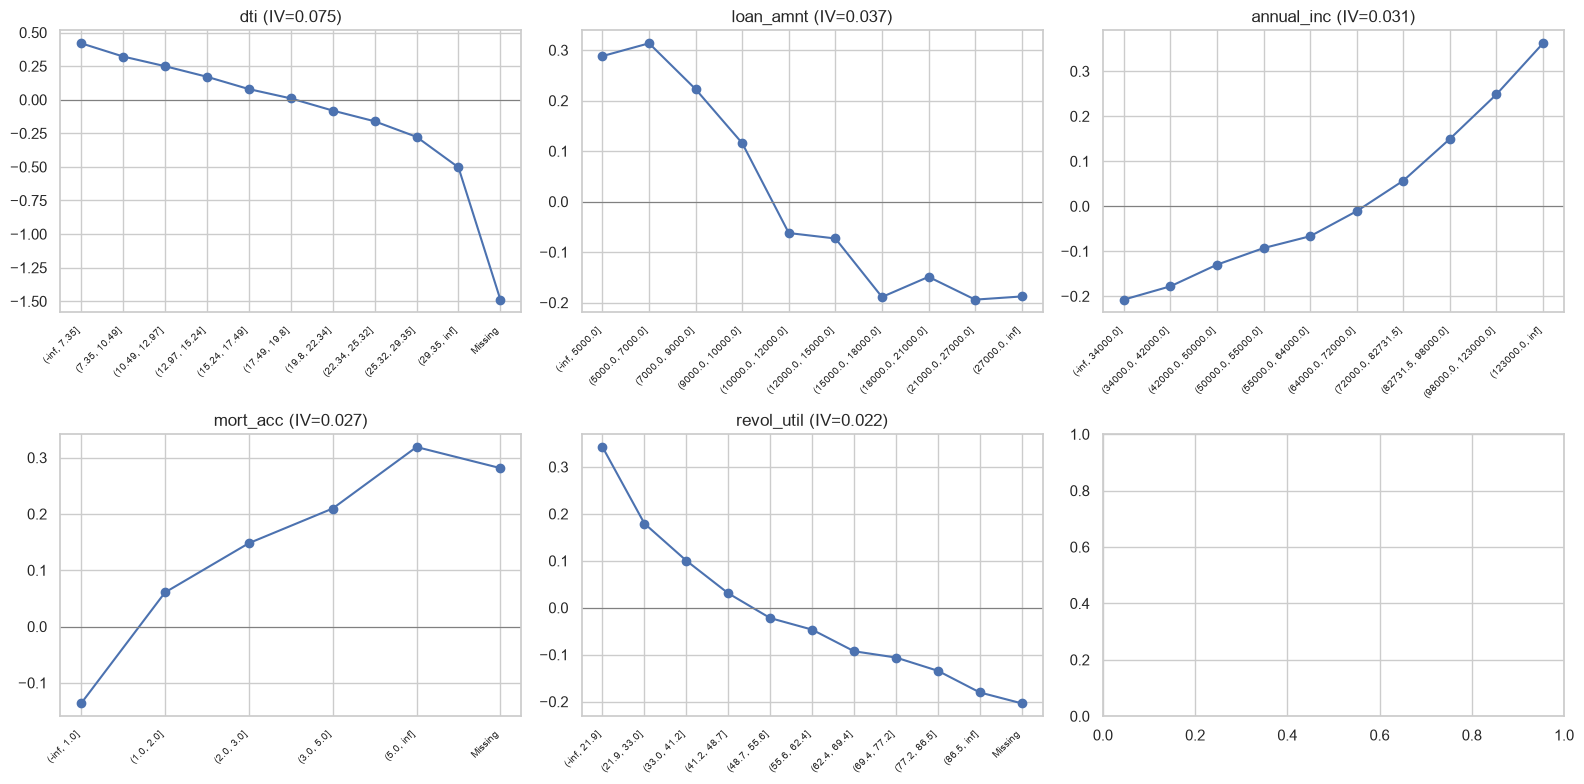

In [6]:
def sort_bins(tab):
    """Sort interval bins by their left edge, pushing the Missing bin to the end."""
    def sort_key(bin_label):
        if isinstance(bin_label, pd.Interval):
            return (0, bin_label.left)
        return (1, 0)
    order = sorted(tab.index, key=sort_key)
    return tab.loc[order]


top_numeric = [f for f in SELECTED_FEATURES if f in NUMERIC_FEATURES][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, top_numeric):
    tab = sort_bins(woe_tables[feat])
    ax.plot(range(len(tab)), tab["woe"], marker="o")
    ax.set_xticks(range(len(tab)))
    ax.set_xticklabels([str(i) for i in tab.index], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{feat} (IV={iv_summary[feat]:.3f})")
    ax.axhline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

## 4. Transform train & test to WOE features

In [7]:
def transform_to_woe(data, features):
    out = pd.DataFrame(index=data.index)
    for feat in features:
        woe_tab = woe_tables[feat]
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        mapped = binned.map(woe_tab["woe"])
        # bin present in test but not seen in train (e.g. novel category) -> WOE 0 (neutral)
        out[feat] = mapped.fillna(0.0)
    return out

X_train = transform_to_woe(train, SELECTED_FEATURES)
X_test = transform_to_woe(test, SELECTED_FEATURES)
y_train = train["is_default"].values
y_test = test["is_default"].values

X_train.shape, X_test.shape

((826606, 8), (293105, 8))

## 5. Fit logistic regression on WOE features

In [8]:
model = LogisticRegression(solver="lbfgs")
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_[0], index=SELECTED_FEATURES).sort_values()
print("Intercept:", model.intercept_[0])
coef_table

Intercept: -1.4876790100443187


term_months           -0.992362
annual_inc            -0.989783
home_ownership        -0.883617
mort_acc              -0.679955
revol_util            -0.616395
dti                   -0.611685
verification_status   -0.545570
loan_amnt             -0.162624
dtype: float64

Every WOE coefficient should be **negative**: a higher WOE means more good (safe) borrowers in that bin, so it should push the predicted probability of default *down*. A positive coefficient signals a badly-behaved variable.

In [9]:
bad_sign = coef_table[coef_table > 0]
if len(bad_sign):
    print("WARNING - unexpected positive coefficients:", bad_sign.index.tolist())
else:
    print("All coefficients have the expected negative sign.")

All coefficients have the expected negative sign.


## 6. Out-of-sample performance: AUC, Gini, KS

In [10]:
def ks_statistic(y_true, y_score):
    order = np.argsort(y_score)
    y_true_sorted = np.array(y_true)[order]
    cum_bad = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    cum_good = np.cumsum(1 - y_true_sorted) / (1 - y_true_sorted).sum()
    return np.max(np.abs(cum_bad - cum_good))


def report_performance(y_true, proba, label):
    auc = roc_auc_score(y_true, proba)
    gini = 2 * auc - 1
    ks = ks_statistic(y_true, proba)
    print(f"{label:>12}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    return auc, gini, ks

train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

train_perf = report_performance(y_train, train_proba, "Train (IS)")
test_perf = report_performance(y_test, test_proba, "Test (OOS)")

  Train (IS): AUC=0.6738  Gini=0.3475  KS=0.2541
  Test (OOS): AUC=0.6593  Gini=0.3186  KS=0.2258


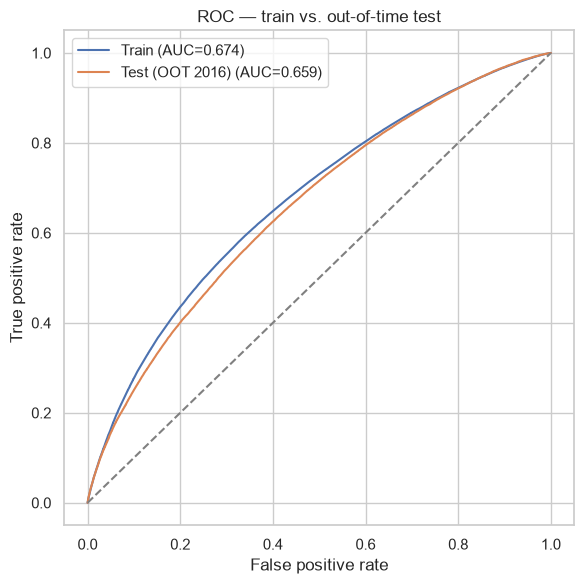

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
for y_true, proba, label in [(y_train, train_proba, "Train"), (y_test, test_proba, "Test (OOT 2016)")]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC — train vs. out-of-time test")
ax.legend()
plt.tight_layout()
plt.show()

A modest gap between train and test AUC/KS is expected and healthy (some overfitting to train, and 2016 is a genuinely different time period). A *large* gap would suggest overfitting or instability; near-identical or better OOS performance would be suspicious.

## 7. Convert to a points-based scorecard

Standard scaling: choose a base score and base odds, plus points-to-double-odds (PDO), then distribute the logistic regression's log-odds contribution across bins as points.

In [12]:
BASE_SCORE = 600
BASE_ODDS = 50   # odds of good:bad at the base score
PDO = 20         # points to double the odds

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

n_features = len(SELECTED_FEATURES)
base_points = offset + factor * model.intercept_[0]

scorecard_rows = []
for feat, coef in zip(SELECTED_FEATURES, model.coef_[0]):
    tab = woe_tables[feat]
    for bin_label, row in tab.iterrows():
        points = -(coef * row["woe"] + model.intercept_[0] / n_features) * factor + offset / n_features
        scorecard_rows.append({
            "feature": feat,
            "bin": bin_label,
            "n_train": int(row["n"]),
            "bad_rate_train": row["bad"] / row["n"],
            "woe": row["woe"],
            "points": round(points, 1),
        })

scorecard = pd.DataFrame(scorecard_rows)
scorecard.head(20)

,feature,bin,n_train,bad_rate_train,woe,points
0,term_months,36.0,618584,0.138954,0.336202,75.9
1,term_months,60.0,208022,0.318952,-0.729206,45.4
2,dti,"(-inf, 7.35]",82773,0.129233,0.419946,73.7
3,dti,"(7.35, 10.49]",82594,0.140712,0.321578,71.9
4,dti,"(10.49, 12.97]",82617,0.149642,0.249604,70.7
5,dti,"(12.97, 15.24]",82770,0.159949,0.170803,69.3
6,dti,"(15.24, 17.49]",82759,0.172658,0.079106,67.7
7,dti,"(17.49, 19.8]",82791,0.182773,0.009871,66.4
8,dti,"(19.8, 22.34]",82444,0.196691,-0.080690,64.8
9,dti,"(22.34, 25.32]",82711,0.209609,-0.160511,63.4


In [13]:
# Vectorized scoring using the fitted WOE features directly (equivalent to summing scorecard points)
def compute_scores(X_woe):
    # model predicts P(is_default=1) i.e. "bad", so its raw log-odds are log-odds of BAD.
    # A credit score should rise with safety, so we negate to get log-odds of good.
    log_odds_bad = model.intercept_[0] + X_woe.values @ model.coef_[0]
    log_odds_good = -log_odds_bad
    return offset + factor * log_odds_good

train_scores = compute_scores(X_train)
test_scores = compute_scores(X_test)

train["score"] = train_scores
test["score"] = test_scores

print(train["score"].describe())
print(test["score"].describe())

count    826606.000000
mean        533.493873
std          18.071725
min         480.777376
25%         522.215025
50%         535.841916
75%         546.610510
max         580.928332
Name: score, dtype: float64
count    293105.000000
mean        534.998645
std          16.920104
min         472.142756
25%         525.106362
50%         536.444922
75%         547.027381
max         580.928332
Name: score, dtype: float64


In [14]:
# Sanity check: summing each loan's per-bin scorecard points should reproduce compute_scores()
# exactly. This catches sign/scaling bugs between the "points table" and the scoring function.
def points_lookup(data, features):
    total = pd.Series(0.0, index=data.index)
    for feat in features:
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        points_map = scorecard[scorecard["feature"] == feat].set_index("bin")["points"]
        total = total + binned.map(points_map).fillna(0.0)
    return total

sample_idx = train.sample(2000, random_state=0).index
points_check = points_lookup(train.loc[sample_idx], SELECTED_FEATURES)
score_check = pd.Series(compute_scores(X_train.loc[sample_idx]), index=sample_idx)
max_diff = (points_check - score_check).abs().max()
print(f"Max |points-table score - compute_scores()| over sample: {max_diff:.4f}")
assert max_diff < 1.0, "Points table and compute_scores() disagree — sign/scaling bug."

Max |points-table score - compute_scores()| over sample: 0.2547


Also, a higher score must correspond to a **lower** observed bad rate. Checking this on the training data before trusting the out-of-time results below.

In [15]:
train_score_check = pd.qcut(train["score"], 5, duplicates="drop")
direction_check = train.groupby(train_score_check, observed=True)["is_default"].mean()
print(direction_check)
assert direction_check.iloc[0] > direction_check.iloc[-1], "Score is inverted: lowest band should have the highest default rate."
print("Score direction confirmed: higher score -> lower default rate.")

score
(480.776, 517.898]    0.348745
(517.898, 531.321]    0.209784
(531.321, 540.03]     0.155617
(540.03, 549.088]     0.123984
(549.088, 580.928]    0.083111
Name: is_default, dtype: float64
Score direction confirmed: higher score -> lower default rate.


## 8. Score distribution & calibration on the out-of-time test set

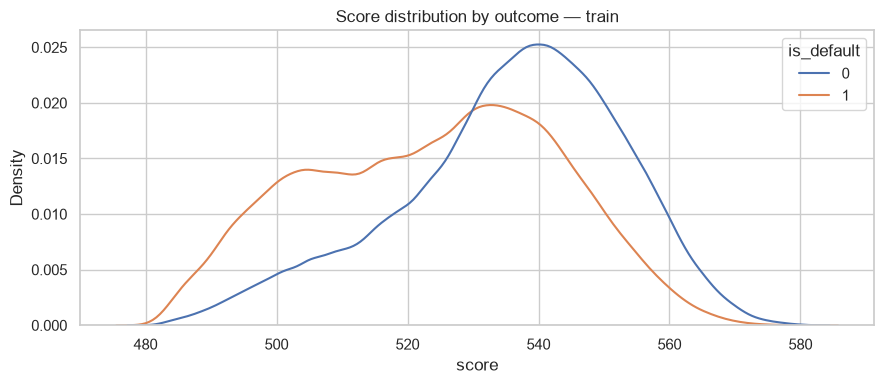

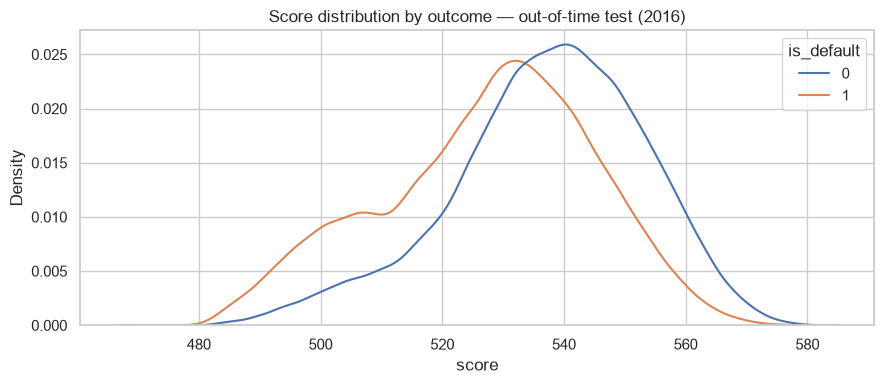

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=train, x="score", hue="is_default", common_norm=False, ax=ax)
ax.set_title("Score distribution by outcome — train")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=test, x="score", hue="is_default", common_norm=False, ax=ax)
ax.set_title("Score distribution by outcome — out-of-time test (2016)")
plt.tight_layout()
plt.show()

In [17]:
test["score_band"] = pd.qcut(test["score"], 10, duplicates="drop")
calibration = test.groupby("score_band", observed=True).agg(
    n=("is_default", "size"),
    actual_default_rate=("is_default", "mean"),
    avg_score=("score", "mean"),
).sort_values("avg_score", ascending=False)
calibration

,n,actual_default_rate,avg_score
score_band,,,
"(555.638, 580.928]",29311,0.090307,561.315087
"(549.467, 555.638]",29310,0.133026,552.371278
"(544.693, 549.467]",29309,0.158723,547.033383
"(540.519, 544.693]",29185,0.182354,542.571974
"(536.445, 540.519]",29436,0.203288,538.496662
"(532.378, 536.445]",29310,0.229205,534.422228
"(527.839, 532.378]",29312,0.255561,530.177198
"(521.796, 527.839]",29311,0.280680,525.011148
"(511.131, 521.796]",29310,0.336472,517.095940


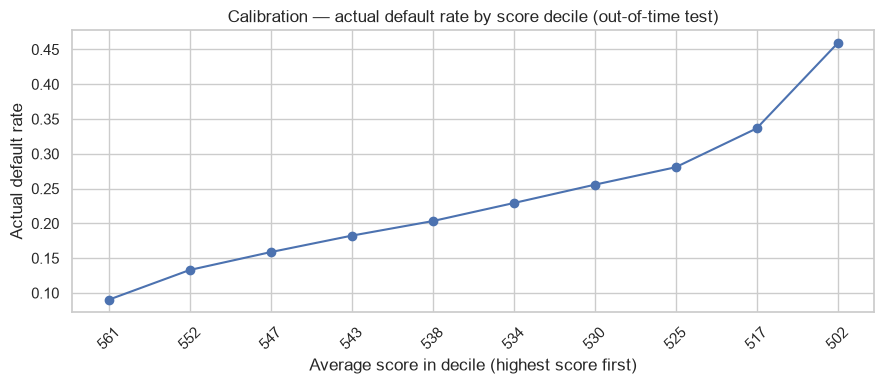

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(calibration)), calibration["actual_default_rate"], marker="o")
ax.set_xticks(range(len(calibration)))
ax.set_xticklabels([f"{v:.0f}" for v in calibration["avg_score"]], rotation=45)
ax.set_xlabel("Average score in decile (highest score first)")
ax.set_ylabel("Actual default rate")
ax.set_title("Calibration — actual default rate by score decile (out-of-time test)")
plt.tight_layout()
plt.show()

A well-calibrated, discriminating scorecard shows actual default rate falling
steadily as score rises (moving left to right through deciles from highest to
lowest score) with no reversals.

## 9. Population Stability Index (PSI): train vs. out-of-time test score distributions

PSI checks whether the *population* being scored has drifted between build and test periods — a separate question from accuracy. PSI < 0.1 is stable, 0.1–0.25 is a moderate shift worth monitoring, > 0.25 signals the population has changed materially.

In [19]:
def psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    edges = np.unique(edges)
    e_counts = np.histogram(expected, bins=edges)[0] / len(expected)
    a_counts = np.histogram(actual, bins=edges)[0] / len(actual)
    e_counts = np.where(e_counts == 0, 1e-6, e_counts)
    a_counts = np.where(a_counts == 0, 1e-6, a_counts)
    return np.sum((a_counts - e_counts) * np.log(a_counts / e_counts))

psi_value = psi(train["score"].values, test["score"].values)
print(f"PSI (train -> 2016 test): {psi_value:.4f}")

PSI (train -> 2016 test): 0.0157


## 10. Summary

- Model trained on 2007–2015 vintages, validated out-of-time on 2016 vintage loans (2017–2018 excluded due to immaturity/right-censoring).
- Uses only applicant/bureau features available at origination — LendingClub's own grade/sub-grade/interest rate are excluded to avoid leaking their risk decision into the model.
- See the printed AUC / Gini / KS above for train vs. out-of-time test performance, the coefficient sign check for variable stability, the calibration table for how well predicted risk ranks match actual out-of-time default rates, and the PSI for population drift.
- `scorecard` (the points table) is the deployable artifact: sum a loan's points across bins for a final score, compare against a chosen cutoff score to approve/decline or to price risk.